In [1]:
cd ~/code/glymphopt

/home/jorgen/programs/Dropbox (Simula)/code/glymphopt


In [2]:
import time
import dolfin as df
import matplotlib.pyplot as plt
import numpy as np
import pantarei as pr
import ufl
import subprocess
from glymphopt.utils import apply_affine, cell_midpoints
from glymphopt.measure import create_index_to_coordinates_affine_map, interpolation_measurement, quadrature_measurement
from glymphopt.visual import plot_step

import itertools
from tqdm import tqdm
import nibabel

In [3]:
expr = " + ".join([
    f"(abs(x[{i}]) <= 1 ? 1 : 0.4) * (exp(-pow((x[{i}] - 0.7)/a1, 2)) + 0.5*exp(-pow((x[{i}] + 0.6)/a1, 2)))"
    for i in range(3)
])

# Define "true" function
f = df.Expression(
    expr,
    degree=3, a1=0.4
)

In [4]:
def apply_affine(T, X):
    A = T[:-1, :-1]
    b = T[:-1, -1]
    return A.dot(X.T).T + b

def grid_to_ras_affine(domain: df.Mesh, shape: tuple[int, int, int]):
    points = domain.coordinates()
    pmin = points.min(axis=0)
    pmax = points.max(axis=0)
    return bbox_to_affine3D(pmin, pmax, shape)

def bbox_to_affine3D(pmin, pmax, shape):
    if isinstance(shape, int):
        shape = (shape, shape, shape)
    ni, nj, nk = shape
    xmin, ymin, zmin = pmin
    xmax, ymax, zmax = pmax

    dim = 3
    A = np.zeros((dim, dim))
    A[0, 0] = -(xmax - xmin) / ni
    A[1, 2] = (ymax - ymin) / nk
    A[2, 1] = -(zmax - zmin) / nj

    p0 = np.array([-1/2, -1/2, -1/2])
    q0 = np.array([xmax, ymin, zmax])
    b = q0 - A.dot(p0)

    T = np.zeros((dim+1, dim+1))
    T[-1, -1] = 1.0
    T[:-1, :-1] = A
    T[:-1, -1] = b

    return T


def measure_function(
    f: ufl.Coefficient,
    img: nibabel.freesurfer.mghformat.MGHImage,
) -> nibabel.freesurfer.mghformat.MGHImage:
    """Measure function from 3D-domain in a regular 3D-grid through interpolation 
    of grid-centerpoints, and output as a Nifti1-image."""
    grid = image_grid(img)
    
    V = df.FunctionSpace(grid, "DG", 0)
    u = df.interpolate(f, V)
    z = V.tabulate_dof_coordinates()
    
#     aff = img.affine
    aff = img.affine
    ind = np.rint(apply_affine(np.linalg.inv(aff), z)).astype(int)
    D = np.nan * np.zeros(img.get_fdata().shape, dtype=np.float32)  
    i, j, k = ind.T
#     y = apply_affine(np.linalg.inv(aff), z)
    D[i, j, k] = u.vector()[:]
#     D = D.astype(np.float32)
    return nibabel.freesurfer.mghformat.MGHImage(D, img.affine)

def mri2fem_interpolate(D, lambda_, V, datafilter=None):
    if datafilter is not None:
        D = datafilter(D)
    u = df.Function(V)
    z = V.tabulate_dof_coordinates()
    ind = np.rint(apply_affine(np.linalg.inv(lambda_), z)).astype(int)
    i, j, k = ind.T
    u.vector()[:] = D[i, j, k]
    return u

def image_grid(img):
    aff = img.affine
    D = img.get_fdata()

    z = np.array([
        [0, 0, 0],
        D.shape
    ])
    corners = apply_affine(aff, z-1/2)
    pmin, pmax = corners.min(axis=0), corners.max(axis=0)
    return df.BoxMesh.create(
        [df.Point(pmin), df.Point(pmax)],
        D.shape,
        df.CellType.Type.hexahedron,
    )

def create_image(pmin, pmax, resolution):
    if isinstance(resolution, int):
        resolution = (resolution, resolution, resolution)
    D = np.nan * np.zeros(resolution, dtype=np.single)
    affine = bbox_to_affine3D(pmin, pmax, resolution)
    return nibabel.freesurfer.mghformat.MGHImage(D, affine)

class InDomain(df.UserExpression):
    """Assign values from a dict to cells labeled by subdomains."""
    def __init__(
        self,
        mesh: df.Mesh,
        extrapolation_value: float = np.nan,
        **kwargs,
    ):
        super().__init__(kwargs)
        self.mesh = mesh
        self.extrapolation_val = extrapolation_value

    def eval_cell(self, value, x, ufc_cell):
        if in_domain(x, self.mesh):
            value[0] = 1.0
        else:
            value[0] = self.extrapolation_val

    def value_shape(self):
        return ()

def in_domain(x, domain):
    """Check if point x lies within a domain."""
    first_entity = domain.bounding_box_tree().compute_first_entity_collision(
        df.Point(x)
    )
    return first_entity <= domain.num_entities(domain.geometric_dimension())

In [5]:
# # Define MRI-domain/grid, and perform measurement, i.e. map function to array of values
# resolution_grid = 64
# shape = (resolution_grid, resolution_grid, resolution_grid)
# pmin = np.array([-2, -2, -2])
# pmax = np.array([+2, +2, +2])
# img_base = create_image(pmin, pmax, shape)
# img = measure_function(f, img_base)
# nibabel.save(img, f"testimage.mgz")


# # Create domain / "brain"
# nx, ny, nz = (27, 27, 27)
# # nx, ny, nz = (2, 2, 2)
# domain_min = df.Point(-1, -1, -1)
# domain_max = df.Point(1, 1, 1)
# domain = df.BoxMesh(domain_min, domain_max, nx, ny, nz)

meshpath = "MRIDATA/MODELING/resolution8/mesh.hdf"
impath = "MRIDATA/NORMALIZED/20230213_144732.mgz"
img_base = nibabel.freesurfer.mghformat.load(impath)
domain = pr.hdf2fenics(meshpath, True)
nibabel.save(img_base, "reference_image.mgz")

In [6]:
D_d = img_base.get_fdata()
aff_d = img_base.header.get_vox2ras_tkr()
aff_d = img_base.affine

CG1 = df.FunctionSpace(domain, "CG", 1)
ch = mri2fem_interpolate(D_d, aff_d, CG1)
ch.set_allow_extrapolation(True)

with df.XDMFFile(df.MPI.comm_world, "testxdmf.xdmf") as xdmf:
    xdmf.write(ch)

In [7]:
maskfunc = InDomain(domain)

tic = time.time()
mask =  measure_function(maskfunc, img_base).get_fdata()
toc = time.time()
print(f"Masked in {toc - tic:.3f}s")

Masked in 151.824s


In [9]:
maskimage_ras = nibabel.freesurfer.mghformat.MGHImage(
    mask.astype(np.float32),
    img_base.affine,
    header=img_base.header,
)
nibabel.save(maskimage_ras, "mask_image_ras.mgz")
maskimage_tkr = nibabel.freesurfer.mghformat.MGHImage(
    mask.astype(np.float32),
    img_base.header.get_vox2ras_tkr(),
)
nibabel.save(maskimage_tkr, "mask_image_tkr.mgz")

In [10]:
tic = time.time()
M_p = measure_function(ch, img_base)
toc = time.time()
print(f"Interpolated in {toc - tic:.3f}s")
M_p._dataobj *= mask

nibabel.save(M_p, "processed_image.mgz")
D_p = M_p.get_fdata()

Building point search tree to accelerate distance queries.
Computed bounding box tree with 393773 nodes for 196887 points.
Interpolated in 618.374s


In [33]:
D_d[D_d == 0] = np.nan

In [34]:
def rel_voxelwise_err(D_p, D_d, f = None):
    e = (D_p - D_d)
    if f is None:
        return (D_p - D_d) / D_d
    return f(D_p) - f(D_d) / f(D_d)
    
    
def mean_relative_voxelwise_err(D_p, D_d):
    return (D_p - D_d) / np.nanmean(D_d)


def median_relative_voxelwise_err(D_p, D_d):
    return (D_p - D_d) / np.nanmedian(D_d)


from scipy.spatial import distance

def global_p_norm_error(D_p, D_d, p):
    mask = ~np.isnan(D_p)
    vec_p, vec_d = D_p[mask], D_d[mask]
    return np.linalg.norm(vec_p - vec_d, ord=p) /  (np.linalg.norm(vec_p, ord=p) * np.linalg.norm(vec_d, ord=p))

def global_cosine_error(D_p, D_d):
    mask = ~np.isnan(D_p)
    vec_p, vec_d = D_p[mask], D_d[mask]
    return distance.cosine(vec_p, vec_d)


def global_score_error(D_p, D_d, f):
    mask = ~np.isnan(D_p)
    vec_p, vec_d = D_p[mask], D_d[mask]
    return (f(vec_p) - f(vec_d)) / f(vec_d)

In [35]:
print("Global 1-norm error:", global_p_norm_error(D_p, D_d, 1))
print("Global 2-norm error:", global_p_norm_error(D_p, D_d, 2))
print("Global cosine-error:", global_cosine_error(D_p, D_d))
print("Global mean   error:", global_score_error(D_p, D_d, np.mean))
print("Global median error:", global_score_error(D_p, D_d, np.median))

Global 1-norm error: nan
Global 2-norm error: nan
Global cosine-error: 0
Global mean   error: nan
Global median error: nan


In [36]:
np.nanmedian(D_d)
np.nanmean(D_d)

0.22254192797624023

In [30]:
e[(~np.isnan(e))*(e < np.inf)*(np.abs(e) > 1e-12)]

array([-0.14781903, -0.15146825, -0.14117375, ..., -0.18457062,
       -0.07531281, -0.16197288])

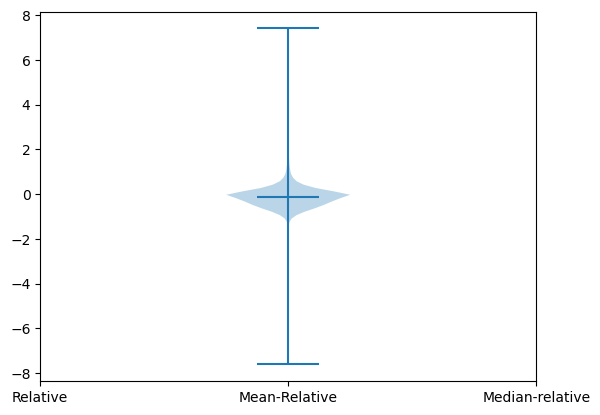

In [41]:
e = rel_voxelwise_err(D_p, D_d)
e_mean = mean_relative_voxelwise_err(D_p, D_d)
e_median = median_relative_voxelwise_err(D_p, D_d)

plt.figure()
# plt.violinplot(e[(~np.isnan(e))*(e < np.inf)], [0], showmeans=True)
plt.violinplot(e_mean[~np.isnan(e_mean)], [1], showmeans=True)
# plt.violinplot(e_median[~np.isnan(e_median)], [2], showmeans=True)
plt.xticks([0, 1, 2], ["Relative", "Mean-Relative", "Median-relative"])

plt.show()

Show image-comparison between MRI-data, processed MRI and the relative voxelwise error. 

In [18]:
import matplotlib.cm as mplcmaps
import matplotlib.colors as mplcolors

slice_ = np.s_[:, :, resolution_grid // 2]
figwidth = 12

title_height = 10
im_height = 64
cbar_height = 10
im_width = 64

total_width = 3 * im_width
total_height = title_height + im_height + cbar_height
aspect_ratio = total_height / total_width
figheight = figwidth * aspect_ratio

fig = plt.figure(figsize=(figwidth, figheight))


# Create Titles
for idx, title in enumerate(["Data", "Processed", "Relative error"]):
    rect = [
        idx * im_width / total_width,
        1 - title_height / total_height,
        im_width / total_width,
        title_height / total_height,
    ]
    ax = fig.add_axes(rect, xticks=[], yticks=[])
    ax.set_frame_on(False)
    ax.text(0.5, 0.5, title, fontsize=18, horizontalalignment="center")

## Plot Images
# data
cmin = min(np.min(D_d[slice_]), np.min(D_p[slice_]))
cmax = max(np.max(D_d[slice_]), np.max(D_p[slice_]))

ax = fig.add_axes(
    rect = [
        0.0 / total_width,
        1 - (title_height + im_height) / total_height,
        im_width / total_width,
        im_height / total_height,
    ],
    xticks=[],
    yticks=[]
)
ax.imshow(D_d[slice_], vmin=cmin, vmax=cmax, cmap="magma")

# processed
rect = [
    im_width / total_width,
    1 - (title_height + im_height) / total_height,
    im_width / total_width,
    im_height / total_height,
]
ax = fig.add_axes(rect, xticks=[], yticks=[])
ax.imshow(D_p[slice_], vmin=cmin, vmax=cmax, cmap="magma")

# error
error_range = max(abs(np.nanmin(e[slice_])), abs(np.nanmax(e[slice_])))
rect = [
    2 * im_width / total_width,
    1 - (title_height + im_height) / total_height,
    im_width / total_width,
    im_height / total_height,
]
ax = fig.add_axes(rect, xticks=[], yticks=[])
ax.imshow(e_mean[slice_], vmin=-error_range, vmax=error_range, cmap="coolwarm")

##  Plot colorbars
rect = [
    0.0,
    0.0,
    2 * im_width / total_width,
    cbar_height / total_height
]
cax1 = fig.add_axes(rect, xticks=[], yticks=[])
cax1.set_frame_on(False)

cmap = mplcmaps.magma
norm = mplcolors.Normalize(vmin=cmin, vmax=cmax)
c = fig.colorbar(
    mplcmaps.ScalarMappable(norm=norm, cmap=cmap),
    ax=cax1,
    orientation="horizontal",
    label="Value",
    fraction=1,
    aspect=40,
)
c.ax.xaxis.set_label_position("bottom")
c.ax.xaxis.set_ticks_position("bottom")

rect = [
    2 * im_width / total_width,
    0.0,
    im_width / total_width,
    cbar_height / total_height
]
cax2 = fig.add_axes(rect, xticks=[], yticks=[])
cax2.set_frame_on(False)
cmap = mplcmaps.coolwarm
norm = mplcolors.Normalize(vmin=-error_range, vmax=error_range)
c = fig.colorbar(
    mplcmaps.ScalarMappable(norm=norm, cmap=cmap),
    ax=cax2,
    orientation="horizontal",
    label="Error",
    fraction=1,
)
c.ax.xaxis.set_label_position("bottom")
c.ax.xaxis.set_ticks_position("bottom")

plt.savefig("mri-comparison.pdf")
plt.show()

NameError: name 'resolution_grid' is not defined